In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import fft
import cv2

(<Figure size 900x300 with 3 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'FT Amplitude'}>,
        <Axes: title={'center': 'FT Log Amplitude'}>], dtype=object))

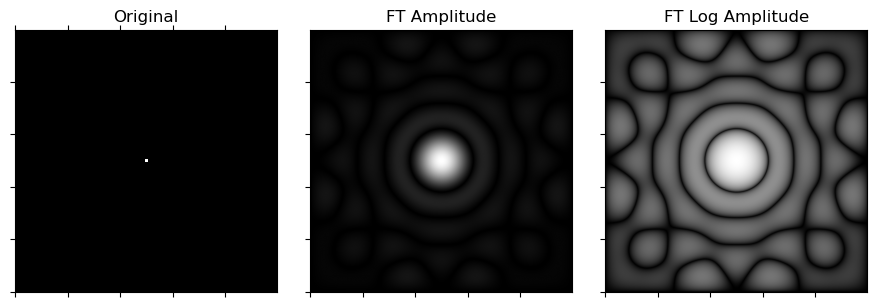

In [4]:
#Basic 2D FT
def plot_imgft(input_image):
    '''
    We're gonna visualize this thing several times,
    so we might as well put it in a function.
    '''
    # Perform 2D FFT, then use fftshift
    # to make sure the zero-frequency is
    # as the center of the image. 
    Zft = fft.fft2(input_image)
    Zft = fft.fftshift(Zft)

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    ## 
    axs[0].matshow(input_image, cmap="gray", origin="lower")
    axs[0].set_title("Original")
    ##
    axs[1].imshow(np.abs(Zft), cmap="gray", origin="lower")
    axs[1].set_title("FT Amplitude")
    ##
    axs[2].imshow(np.log(1 + np.abs(Zft)), cmap="gray", origin="lower")
    axs[2].set_title("FT Log Amplitude")

    ## Cosmetic
    for ax in axs:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    fig.tight_layout()

    return fig, axs
    
# Produce a "meshgrid"
pos = np.linspace(-10, 10, 1000)
X, Y = np.meshgrid(pos, pos)

Z = X**2 + Y**2
Z = 1*(Z < 0.01)

plot_imgft(Z)

(<Figure size 900x300 with 3 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'FT Amplitude'}>,
        <Axes: title={'center': 'FT Log Amplitude'}>], dtype=object))

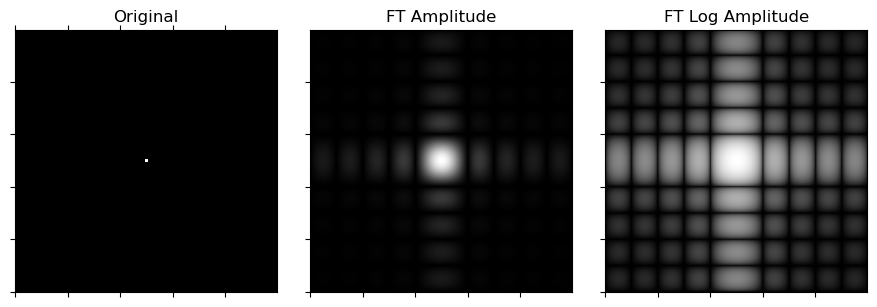

In [9]:
l=0.1
Z = 1*(X>-l)*(X<l)*(Y>-l)*(Y<l)
plot_imgft(Z)

(<Figure size 900x300 with 3 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'FT Amplitude'}>,
        <Axes: title={'center': 'FT Log Amplitude'}>], dtype=object))

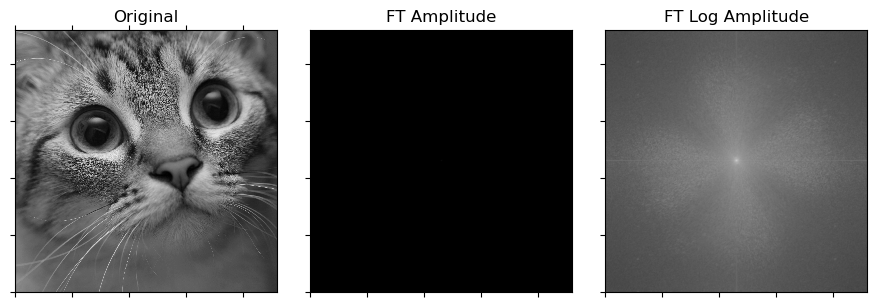

In [12]:
the_cat = np.load("the_cat.npy.txt")
the_cat = np.flipud(the_cat)

plot_imgft(the_cat)

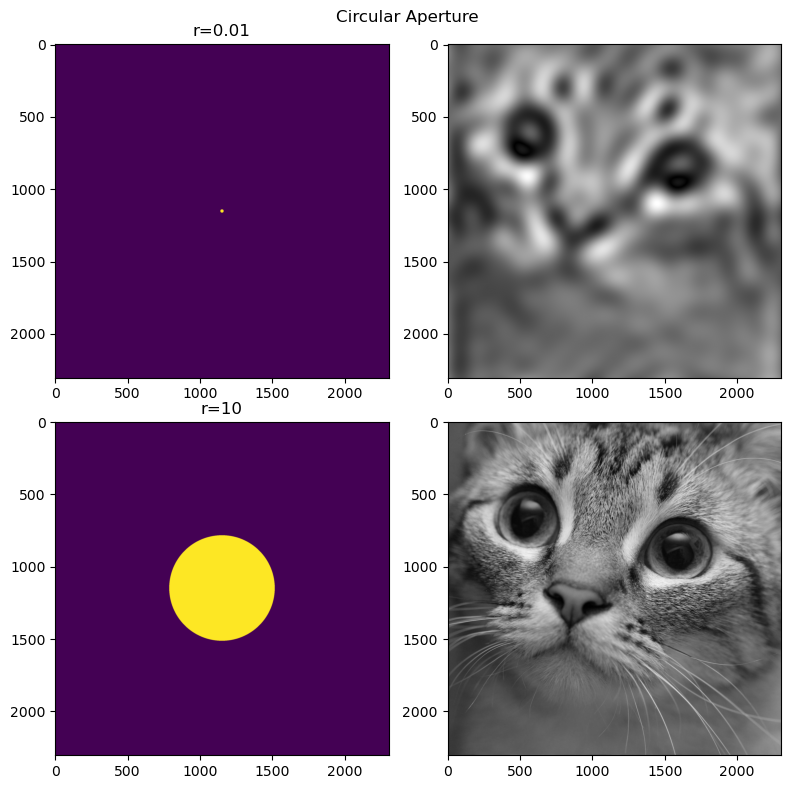

In [153]:
# Radial aperture
pos = np.linspace(-10, 10, 2304)
X, Y = np.meshgrid(pos, pos)

aper=X**2+Y**2

r1 = 0.01
r2 = 10

aper1=1*(aper<r1) #small aperture
aper2=1*(aper<r2) #big aperture

#Image
cat = np.load("the_cat.npy.txt")
cat_ft = fft.fft2(cat)
cat_ft = fft.fftshift(cat_ft)

#product of fft of image and the aperture
prod1 = (cat_ft*aper1)
prod2 = (cat_ft*aper2)

#FT of product 
out1_ft = np.flipud(fft.fft2(prod1))
out2_ft = np.flipud(fft.fft2(prod2))

#plt.imshow(np.abs(out_ft), cmap="gray")

fig,axs = plt.subplots(2,2, figsize=(8,8))

fig.suptitle("Circular Aperture")

plt.tight_layout()

axs[0,1].imshow(np.abs(out1_ft), cmap="gray")
axs[1,1].imshow(np.abs(out2_ft), cmap="gray")
axs[0,0].imshow(aper1)
axs[0,0].set_title("r=0.01")
axs[1,0].imshow(aper2)
axs[1,0].set_title("r=10")

plt.savefig("FFT2_circular")

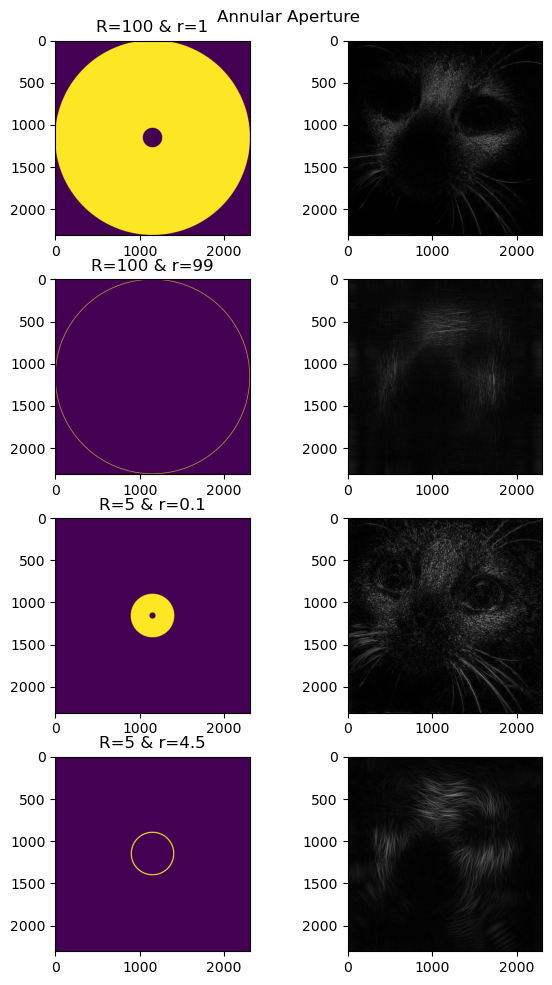

In [154]:
#Annular apperture
pos = np.linspace(-10, 10, 2304)
X, Y = np.meshgrid(pos, pos)

outer_rad1 = 100 #big and wide
inner_rad1 = 1

outer_rad2 = 100 #big and thin
inner_rad2 = 99

outer_rad3 = 5 #small and wide
inner_rad3 = 0.1

outer_rad4 = 5 #small and thin
inner_rad4 = 4.5


aper = (X**2)+(Y**2)

aper1 = (aper<outer_rad1)*(aper>inner_rad1)
aper2 = (aper<outer_rad2)*(aper>inner_rad2)
aper3 = (aper<outer_rad3)*(aper>inner_rad3)
aper4 = (aper<outer_rad4)*(aper>inner_rad4)

#Image
cat = np.load("the_cat.npy.txt")
cat_ft = fft.fft2(cat)
cat_ft = fft.fftshift(cat_ft)

#product of fft of image and the aperture
prod1 = (cat_ft*aper1)
prod2 = (cat_ft*aper2)
prod3 = (cat_ft*aper3)
prod4 = (cat_ft*aper4)

#FT of product 
out1_ft = np.flipud(fft.fft2(prod1))
out2_ft = np.flipud(fft.fft2(prod2))
out3_ft = np.flipud(fft.fft2(prod3))
out4_ft = np.flipud(fft.fft2(prod4))

#plt.matshow(np.abs(out_ft), cmap="gray")
fig,axs = plt.subplots(4,2, figsize=(6,10))

fig.suptitle("Annular Aperture")

plt.tight_layout()

axs[0,0].imshow(aper1)
axs[0,0].set_title("R=100 & r=1")

axs[0,1].imshow(np.abs(out1_ft), cmap="gray")

axs[1,0].imshow(aper2)
axs[1,0].set_title("R=100 & r=99")

axs[1,1].imshow(np.abs(out2_ft), cmap="gray")

axs[2,0].imshow(aper3)
axs[2,0].set_title("R=5 & r=0.1")

axs[2,1].imshow(np.abs(out3_ft), cmap="gray")

axs[3,0].imshow(aper4)
axs[3,0].set_title("R=5 & r=4.5")

axs[3,1].imshow(np.abs(out4_ft), cmap="gray")

plt.savefig("FFT2_annular")